<a href="https://colab.research.google.com/github/robertmadril15/CS4410/blob/main/homework5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

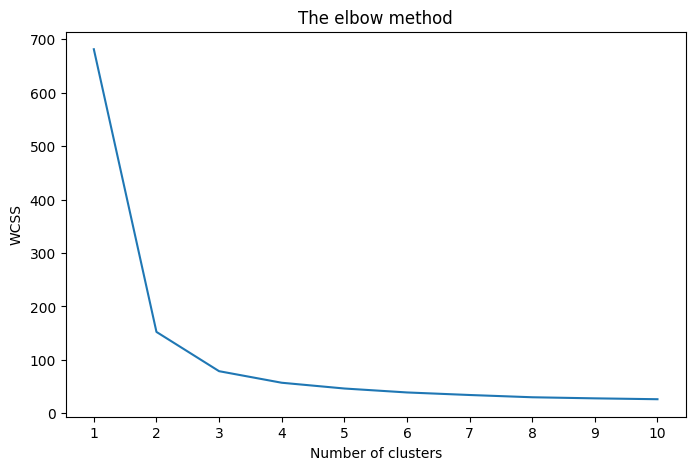

k: 1 intertia: 681.3705999999996
k: 2 intertia: 152.34795176035797
k: 3 intertia: 78.851441426146
k: 4 intertia: 57.22847321428572
k: 5 intertia: 46.44618205128204
k: 6 intertia: 39.066035353535376
k: 7 intertia: 34.29822966507179
k: 8 intertia: 30.063110617452732
k: 9 intertia: 28.024976812661045
k: 10 intertia: 26.393241540115117


In [16]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

iris = load_iris()
x = iris.data

k_range = range(1, 11)
inertia_values = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=11, n_init=10)
    kmeans.fit(x)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia_values)
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title("The elbow method")
plt.xticks(k_range)
plt.show()

for i in range(len(k_range)):
    print("k:", k_range[i], "intertia:", inertia_values[i])

normal features: 784
pca features: 331

time without pca: 45.20s, accuracy without pca: 0.9134
time with pca: 36.03s, accuracy with pca: 0.9218


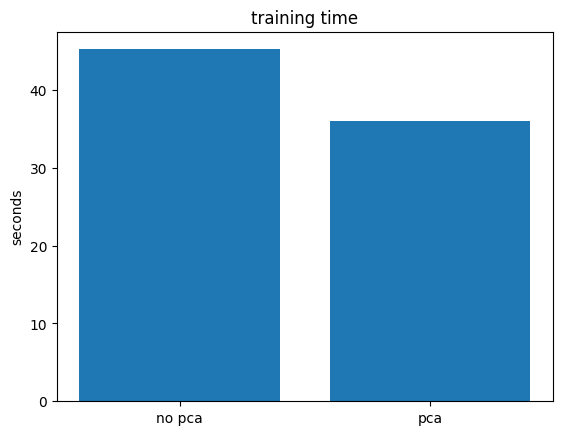

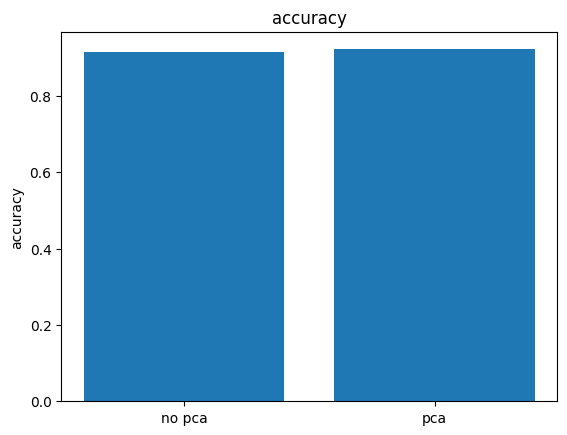

In [19]:
import time
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=11
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

t0 = time.time()
noPca_log = LogisticRegression(solver='lbfgs', max_iter=300, n_jobs=-1)
noPca_log.fit(X_train_scaled, y_train)
noPca_time = time.time() - t0

noPca_pred = noPca_log.predict(X_test_scaled)
noPca_acc = accuracy_score(y_test, noPca_pred)

pca = PCA(0.95, random_state=11)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

t0 = time.time()
pca_log = LogisticRegression(solver='lbfgs', max_iter=300, n_jobs=-1)
pca_log.fit(X_train_pca, y_train)
pca_time = time.time() - t0

pca_pred = pca_log.predict(X_test_pca)
pca_acc = accuracy_score(y_test, pca_pred)

print("normal features:", X_train.shape[1])
print("pca features:", X_train_pca.shape[1])
print()
print(f"time without pca: {noPca_time:.2f}s, accuracy without pca: {noPca_acc:.4f}")
print(f"time with pca: {pca_time:.2f}s, accuracy with pca: {pca_acc:.4f}")

plt.figure()
plt.bar(['no pca', 'pca'], [noPca_time, pca_time])
plt.title('training time')
plt.ylabel('seconds')
plt.show()

plt.figure()
plt.bar(['no pca', 'pca'], [noPca_acc, pca_acc])
plt.title('accuracy')
plt.ylabel('accuracy')
plt.show()

